# Grover's Algorithm and Unstructured Search

While Shor's algorithm completely breaks asymmetric cryptography (like RSA) by solving the period-finding problem in polynomial time, Grover's algorithm represents the primary quantum threat against **symmetric cryptography** (such as AES) and **hash functions**.

Proposed by Lov Grover in 1996, this algorithm solves the unstructured search problem: finding a specific element $w$ within an unsorted database of size $N=2^n$. While a classical processor must iteratively check elements resulting in an $\mathcal{O}(N)$ complexity, Grover's algorithm exploits quantum interference to find the solution in $\mathcal{O}(\sqrt{N})$ evaluations. This quadratic speedup is the exact mathematical reason why standardization agencies strongly recommend doubling symmetric key sizes (e.g., migrating from AES-128 to AES-256) to maintain security in the post-quantum era.

In this notebook, we will build Grover's algorithm from scratch, implementing custom oracles, dynamic diffusion operators, and integrating it with Quantum Phase Estimation (QPE) for Quantum Counting.

## Grover's Algorithm First Approach

In this notebook, we will implement Grover's algorithm using a straightforward approach. Grover's algorithm is designed to search an unsorted database with N entries in $O(\sqrt{N})$ time, which is significantly faster than the classical $O(N)$ time. We are going to follow the IBM Quantum Learning Guide [Quiskit in the classroom](https://quantum.cloud.ibm.com/learning/es/modules/computer-science/grovers).

In [364]:
# Built-in modules
import math

# Imports from Qiskit
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import MCMTGate, ZGate, grover_operator
from qiskit_aer import AerSimulator


## Oracle Implementation

First, we need to create an oracle that marks the solution state. In this example, we will search for the state $|\psi\rangle = |011\rangle$ in a 3-qubit system. We can use the multiple control multiple target gate (`MCMTGate`) to apply a Z gate controlled by all qubits (flip the phase if all qubits are in the $|1\rangle$ state).

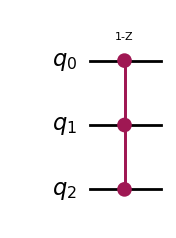

In [365]:
mcmt_ex = QuantumCircuit(3)
mcmt_ex.compose(MCMTGate(ZGate(), 3 - 1, 1), inplace=True)
mcmt_ex.draw(output="mpl", style="iqp")

We have to notice that in the `MCMTGate` multiple qubits could be involved as controls but there is no target. The gate is beeing applied to all the qubits in a equal way.

In [366]:
def grover_oracle(marked_states):
    """Build a Grover oracle for multiple marked states

    Here we assume all input marked states have the same number of bits

    Parameters:
        marked_states (str or list): Marked states of oracle

    Returns:
        QuantumCircuit: Quantum circuit representing Grover oracle
    """
    if not isinstance(marked_states, list):
        marked_states = [marked_states]
    # Compute the number of qubits in circuit
    num_qubits = len(marked_states[0])

    qc = QuantumCircuit(num_qubits)
    # Mark each target state in the input list
    for target in marked_states:
        if len(target) != num_qubits:
            raise ValueError("All marked states must have the same number of bits")
        # Flip target bitstring to match Qiskit bit-ordering
        rev_target = target[::-1]
        # Find the indices of all the '0' elements in bitstring
        zero_inds = [
            ind for ind in range(num_qubits) if rev_target.startswith("0", ind)
        ]
        # Add a multi-controlled Z-gate with pre and post-applied X-gates(open-controls)
        # where the target bitstring has a '0' entry
        qc.x(zero_inds)
        qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
        qc.x(zero_inds)
    return qc

Now we are going to choose an specific state to search for.

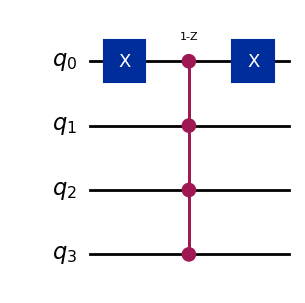

In [367]:
marked_states = ["1110"]
oracle = grover_oracle(marked_states)
oracle.draw(output="mpl", style="iqp")

The full Grover operator consists of the phase query gate (oracle), Hadamard layers, and the $Z_\text{OR}$ operator. We can use the built-in `grover_operator` to construct this from the oracle we defined above.

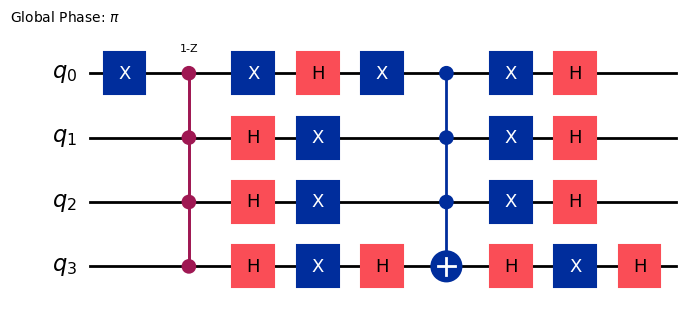

In [368]:
grover_op = grover_operator(oracle)
grover_op.decompose(reps=0).draw(output="mpl", style="iqp")

As we argued above, we may need to apply the Grover operator multiple times. The optimal number of iterations, $t,$ to maximize the amplitude of the target state in the absence of noise can be obtained from this expression:

$$
(2t+1)\theta = (2t+1)\sin^{-1}\left( \sqrt{\frac{|A_1|}{N}}\right) \approx (2t+1)\sqrt{\frac{|A_1|}{N}} \approx \frac{\pi}{2}\\
t\approx \frac{\pi}{4} \sqrt{\frac{N}{|A_1|}}-\frac{1}{2}
$$

Here $A_1$ is the number of solutions or target states. On modern noisy quantum computers, the experimentally optimal number of iterations might be different - but here we calculate and use this theoretical, optimal number using $A_1=1$.

For understanding this I highly recommend to see the [Ket.G video about Grover's sqrt(N) operations](https://www.youtube.com/watch?v=2UzmFiei9h0&list=PLhYoqmIacCv-6t6gCJIuE8Ok8my9y1K_u&index=5).

In [369]:
optimal_num_iterations = math.floor(
    math.pi / (4 * math.asin(math.sqrt(len(marked_states) / 2**grover_op.num_qubits)))
)
print(optimal_num_iterations)

3


Building now the full Grover circuit by applying the Grover operator the calculated number of times to the initial equal superposition state.

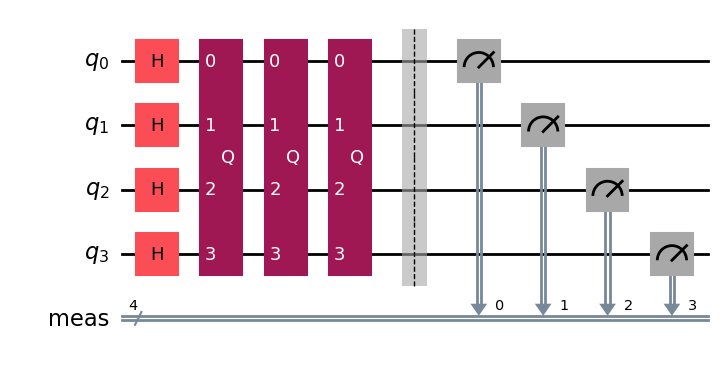

In [370]:
qc = QuantumCircuit(grover_op.num_qubits)
# Create even superposition of all basis states
qc.h(range(grover_op.num_qubits))
# Apply Grover operator the optimal number of times
qc.compose(grover_op.power(optimal_num_iterations), inplace=True)
# Measure all qubits
qc.measure_all()
qc.draw(output="mpl", style="iqp")

In [371]:
simulator = AerSimulator()
transpiled_qc = transpile(qc, simulator)
result = simulator.run(transpiled_qc).result()
counts = result.get_counts()
print(counts)

# final result
most_likely_state = max(counts, key=counts.get)
print(f"Most likely state: {most_likely_state}")

{'0010': 1, '0100': 3, '1110': 986, '1100': 3, '0101': 5, '1001': 4, '1011': 1, '0111': 2, '0011': 2, '0001': 3, '1111': 2, '1000': 3, '0110': 4, '1010': 2, '0000': 3}
Most likely state: 1110


As we can see, the amplitude of the target state $|1110\rangle$ is significantly higher than the others, with a probability of measuring it being approximately 0.9. This demonstrates the effectiveness of Grover's algorithm in amplifying the probability of the target state.

## Grover Diffuser

The engine of amplitude amplification relies on alternating two reflections. Geometrically, the oracle reflects the initial uniform superposition state $\ket{s}$ across the hyperplane orthogonal to the solution. Next, the **Grover Diffuser ($G$)** reflects that intermediate state across the original state $\ket{s}$. 

The composition of these two reflections results in a pure geometric rotation of angle $2\theta$ towards the solution state $\ket{w}$. Because it is a continuous rotation in the Hilbert space, applying the operator infinitely does not guarantee success; if we apply too many iterations, the state vector will overshoot the target and the probability of measuring the correct answer will decrease.

In [372]:
def grover_diffuser(num_qubits: int) -> QuantumCircuit:
    """
    Builds the standard diffusion operator G using Hadamard gates.
    Args:
        num_qubits (int): Number of qubits in the diffusion operator.
    Returns:
        QuantumCircuit: The diffusion operator circuit.
    """
    qc = QuantumCircuit(num_qubits, name="Difusor_G")

    qc.h(range(num_qubits))  # Hadamard gates to create superposition

    # Inversion about the mean
    qc.x(range(num_qubits))
    qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)

    # Redo Hadamard gates to return to the original basis
    qc.x(range(num_qubits))
    qc.h(range(num_qubits))

    # Adding a global phase of π (-1) from I - 2|s><s| to 2|s><s| - I
    qc.global_phase = math.pi

    return qc


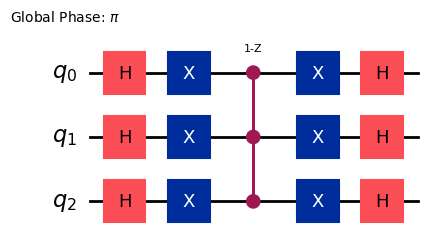

In [373]:
grover_diffuser(3).draw(output="mpl", style="iqp")

## Optimal Number of Iterations 

Using the small-angle approximation for large databases ($N \gg M$), the optimal number of iterations $\mathcal{O}$ required to reach the orthogonal solution axis is strictly bounded by:
$$ \mathcal{O} \approx \left\lfloor \frac{\pi}{4}\sqrt{\frac{N}{M}} \right\rfloor $$

We implement a dynamic calculator to ensure our circuit applies the exact number of optimal loops before measurement.

In [374]:
def calculate_optimal_iterations(num_qubits: int, num_solutions: int = 1) -> int:
    """
    Calculates the optimal number of Grover iterations based on the number of qubits and
    solutions.
    Args:
        num_qubits (int): Number of qubits in the Grover circuit.
        num_solutions (int): Number of solutions to the search problem. Default is 1.
    Returns:
        int: Optimal number of Grover iterations.
    """
    N = 2**num_qubits

    if num_solutions >= N / 2:
        return 0

    # Formula: (pi/4) * sqrt(N/M)
    theta = math.asin(math.sqrt(num_solutions / N))
    optimal_iterations = math.floor(math.pi / (4 * theta))

    return optimal_iterations

Finally, we assemble the full Grover circuit by applying the Grover operator the calculated number of times to the initial equal superposition state.

In [375]:
def grover_algorithm(
    oracle: QuantumCircuit, num_solutions: int = 1, debug: bool = False
) -> QuantumCircuit:
    """
    Assembles the complete Grover algorithm circuit for a given oracle.
    Args:
        oracle (QuantumCircuit): The Grover oracle circuit.
        num_solutions (int): Number of solutions to the search problem. Default is 1.
        debug (bool): If True, prints additional debug information. Default is False.
    Returns:
        QuantumCircuit: The complete Grover algorithm circuit.
    """
    num_qubits = oracle.num_qubits
    qc = QuantumCircuit(num_qubits, num_qubits)

    qc.h(range(num_qubits))  # |s> state preparation

    # Calculate the number of iterations
    iterations = calculate_optimal_iterations(num_qubits, num_solutions)
    if debug:
        print(f"Optimal iterations calculated: {iterations}")

    # Grover Loop
    diffuser = grover_diffuser(num_qubits)
    for _ in range(iterations):
        qc.compose(oracle, inplace=True)
        qc.compose(diffuser, inplace=True)
        qc.barrier()

    qc.measure(range(num_qubits), range(num_qubits))

    return qc


This way, we can simulate the circuit and measure the output. The result should show a high probability of measuring the target state, confirming the effectiveness of Grover's algorithm in finding the desired solution in an unsorted database.

In [376]:
grover_circuit = grover_algorithm(oracle, num_solutions=len(marked_states), debug=True)
transpiled_grover_circuit = transpile(grover_circuit, simulator)
result = simulator.run(transpiled_grover_circuit).result()
counts = result.get_counts()
print(counts)

most_likely_state = max(counts, key=counts.get)
print(f"Most likely state: {most_likely_state}")

Optimal iterations calculated: 3
{'1010': 4, '1111': 5, '1011': 1, '1110': 983, '0000': 1, '0010': 3, '0101': 4, '1001': 3, '1100': 3, '0111': 1, '0011': 2, '0100': 3, '1000': 3, '0110': 2, '1101': 3, '0001': 3}
Most likely state: 1110


## Amplitude Amplification

The standard Grover algorithm uses a Hadamard layer ($H^{\otimes n}$) to generate a blind, uniform superposition of the entire search space. In real-world cryptanalysis, we rarely search completely blind; we often have classical heuristics (e.g., knowing that a password starts with a specific letter or a key avoids certain bit patterns).

Brassard et al. generalized Grover's algorithm into **Amplitude Amplification**. They proved that we can replace the initial Hadamard layer with an arbitrary heuristic algorithm $\mathcal{A}$, which initializes the system in a restricted superposition state $\ket{t} = \mathcal{A}\ket{0}$ containing only the elements that satisfy the classical constraint.

Consequently, the geometric rotation must pivot around this new axis $\ket{t}$. The generalized diffuser swaps the Hadamard matrices for the heuristic algorithm and its inverse:
$$ \mathcal{A} \left( 2\ket{0}\bra{0} - I \right) \mathcal{A}^{-1} $$

Let's demonstrate this practically. Suppose we are searching for the key `|1110>`, but our classical heuristic algorithm reveals that the most significant bit (MSB) must be `1`. We can design an algorithm $\mathcal{A}$ that fixes the MSB to `1` and applies superposition only to the remaining 3 qubits. This reduces our search space from $N=16$ to just $N=8$, significantly reducing the required quantum iterations.

In [377]:
def amplitude_amplification_diffuser(A_circuit: QuantumCircuit) -> QuantumCircuit:
    """
    Builds the generalized diffusion operator A * (2|0><0| - I) * A_inv for Amplitude
    Amplification.
    Args:
        A_circuit (QuantumCircuit): The quantum circuit representing the heuristic A.
    Returns:
        QuantumCircuit: The generalized diffusion operator circuit.
    """
    num_qubits = A_circuit.num_qubits
    qc = QuantumCircuit(num_qubits, name="Difusor_Amp")

    # Apply the inverse of the heuristic
    qc.compose(A_circuit.inverse(), inplace=True)

    # Mean inversion (reflection about |0...0>)
    qc.x(range(num_qubits))
    qc.compose(MCMTGate(ZGate(), num_qubits - 1, 1), inplace=True)
    qc.x(range(num_qubits))

    # Redo the heuristic to return to the original basis
    qc.compose(A_circuit, inplace=True)

    return qc

In [378]:
print("\n--- AMPLITUDE AMPLIFICATION EXPERIMENT ---")

num_qubits = 4

# Define the Heuristic Algorithm A
# We know the MSB (qubit 3) is '1'. The rest are unknown.
A_circ = QuantumCircuit(num_qubits, name="Heuristic_A")
A_circ.x(3)  # Fix MSB to |1>
A_circ.h([0, 1, 2])  # Superposition on the remaining qubits

# Re-calculate optimal iterations for the reduced space
reduced_space = 8 # Search space is now 2^3 = 8 instead of 16
theta_amp = math.asin(math.sqrt(1 / reduced_space))
amp_iterations = math.floor(math.pi / (4 * theta_amp))
print(f"Standard Iterations (N=16): {calculate_optimal_iterations(4)}")
print(f"Heuristic Iterations (N=8): {amp_iterations}")

# Build the Amplitude Amplification Circuit
amp_qc = QuantumCircuit(num_qubits, num_qubits)

amp_qc.compose(A_circ, inplace=True)  # Apply initial state preparation A|0>

gen_diffuser = amplitude_amplification_diffuser(A_circ)  # Generalized diffuser

for _ in range(amp_iterations):  # Grover loop with reduced iterations
    amp_qc.compose(oracle, inplace=True)
    amp_qc.compose(gen_diffuser, inplace=True)

amp_qc.measure(range(num_qubits), range(num_qubits))

# Execute and Validate
compiled_amp = transpile(amp_qc, AerSimulator())
amp_counts = AerSimulator().run(compiled_amp, shots=1024).result().get_counts()

# Ensure we found the correct state with fewer iterations
sorted_amp = sorted(amp_counts.items(), key=lambda item: item[1], reverse=True)
print(f"\nAmplitude Amplification Results: {sorted_amp[:3]}")

most_likely_state_amp = max(amp_counts, key=amp_counts.get)
print(f"Most likely state (Amplitude Amplification): {most_likely_state_amp}")


--- AMPLITUDE AMPLIFICATION EXPERIMENT ---
Standard Iterations (N=16): 3
Heuristic Iterations (N=8): 2

Amplitude Amplification Results: [('1110', 963), ('1111', 12), ('1010', 11)]
Most likely state (Amplitude Amplification): 1110


This way we can find the correct state with fewer iterations, demonstrating the power of amplitude amplification in practical scenarios where classical heuristics can be leveraged to optimize quantum search algorithms.

## Quantum Counting

In a real cryptanalysis scenario (e.g., searching for hash collisions), the attacker does not know how many valid keys ($M$) exist. As demonstrated above, without knowing $M$, we cannot calculate the optimal number of iterations.

To solve this, Brassard et al. combined Grover's operator with the **Quantum Phase Estimation (QPE)** subroutine. In the 2D invariant subspace spanned by the solutions and the wrong states, the Grover operator acts as a rotation matrix. The eigenvalues of this matrix are exactly $e^{\pm i 2\theta}$. 

By passing the entire Grover operator (Oracle + Diffuser) as a controlled unitary gate into our generalized QPE engine, the algorithm extracts this rotational phase. We can then use classical trigonometry to reverse-engineer the exact number of solutions $M$ in the database before running the actual search.

For this implementation, we are going to use the `qpe` function defined in the [Quantum Phase Estimation Notebook](/src/algorithms/3_quantum_primitives/qpe/quantum_phase_estimation.ipynb) to perform the QPE step in the Grover's Quantum Counting algorithm. I highly recommend reviewing that notebook to understand the inner workings of the QPE, as it is a crucial component of Grover's and other quantum algorithms.

Besides, the `iqft` function defined in the [Quantum Fourier Transform Notebook](../3_quantum_primitives/qft/quantum_fourier_transform.ipynb) is used to perform the inverse QFT step in the QPE subroutine. So, for the sake of completeness, I recommend reviewing that notebook too to understand the inner workings of the QFT and its inverse, as it is also a crucial component of Grover's Quantum Counting.

In [379]:
from src.algorithms.quantum_primitives.qpe import qpe

In [380]:
def quantum_counting_circuit(
    estimation_wires: int, oracle: QuantumCircuit
) -> QuantumCircuit:
    """
    Assembles the Quantum Counting circuit by passing the Grover operator through the
    Phase Estimation engine.
    Args:
        estimation_wires (int): Number of qubits in the estimation register.
        oracle (QuantumCircuit): The Grover oracle circuit.
    Returns:
        QuantumCircuit: The complete Quantum Counting circuit.
    """
    target_wires = oracle.num_qubits
    total_qubits = estimation_wires + target_wires

    # 1. Grover operator: U = G * U_f
    grover_op = QuantumCircuit(target_wires, name="Grover_Op")
    grover_op.compose(oracle, inplace=True)
    grover_op.compose(grover_diffuser(target_wires), inplace=True)

    # 2. Apply QPE for autovalue estimation of the Grover operator
    counting_circ = qpe(estimation_wires, operator_u=grover_op)

    # 3. CRITICAL STEP: Prepare the target register in |s> state
    # [CORRECCIÓN]: Añadimos 'estimation_wires' como segundo parámetro
    # para instanciar los bits clásicos necesarios para la medición.
    state_prep = QuantumCircuit(total_qubits, estimation_wires)
    state_prep.h(range(estimation_wires, total_qubits))

    # Combine state preparation with the QPE circuit
    full_counting_circ = state_prep.compose(counting_circ)

    # 4. Measure only the estimation register
    full_counting_circ.measure(range(estimation_wires), range(estimation_wires))

    return full_counting_circ


In [381]:
def post_process_quantum_counting(
    measured_integer: int, estimation_wires: int, target_wires: int
) -> int:
    """
    Applies classical post-processing to extract the number of solutions M.
    Formula: M = N * sin^2(pi * y / 2^m)
    Args:
        measured_integer (int): The integer obtained from measuring the estimation
        register.
        estimation_wires (int): Number of qubits in the estimation register.
        target_wires (int): Number of qubits in the target register.
    Returns:
        int: Estimated number of solutions M.
    """
    N = 2**target_wires
    phase_fraction = measured_integer / (2**estimation_wires)

    # M = N * sin^2(θ) where θ = π * phase
    theta = math.pi * phase_fraction
    M = N * (math.sin(theta) ** 2)

    return int(round(M))  # Round to the nearest integer


To rigorously verify the Quantum Counting algorithm, we will simulate a blind cryptanalysis scenario. We will construct a 4-qubit oracle that marks exactly 3 unknown states. The algorithm will not be provided with this number $M$; instead, it must deduce it purely by estimating the phase of the Grover operator.

We will construct the Grover operator (Oracle + Diffuser) and inject it directly into our Phase Estimation (QPE) engine using a functional approach. By using $m=6$ estimation qubits, we expect the quantum interference to reveal a phase fraction that, through classical trigonometry, resolves to our hidden $M$.

In [382]:
print("\n--- QUANTUM COUNTING EXPERIMENT ---")

# Oracle Setup: 4 qubits (N=16), 3 unknown solutions (M=3)
secret_states = ["0011", "0101", "1110"]
true_M = len(secret_states)
target_wires = 4

counting_oracle = grover_oracle(secret_states)

# Build the Quantum Counting Circuit
estimation_wires = 6  # Using 6 qubits for higher trigonometric precision
counting_circ = quantum_counting_circuit(estimation_wires, counting_oracle)

# Execute on Simulator
print("Transpiling and executing Quantum Counting circuit...")
compiled_counting = transpile(counting_circ, AerSimulator())
counting_results = (
    AerSimulator().run(compiled_counting, shots=2048).result().get_counts()
)

# Extract and Post-Process the most probable state
# The results will have two peaks (e^{i 2\theta} and e^{-i 2\theta}) we take the highest
most_frequent_state = max(counting_results, key=counting_results.get)
measured_integer = int(most_frequent_state, 2)

# Apply the mathematical post-processing formula
estimated_M = post_process_quantum_counting(
    measured_integer=measured_integer,
    estimation_wires=estimation_wires,
    target_wires=target_wires,
)

print("\n--- RESULTS ---")
print(f"Target space size (N): {2**target_wires}")
print(f"True number of solutions (M): {true_M}")
print(
    f"Most frequent measurement: |{most_frequent_state}> (Decimal: {measured_integer})"
)
print(
    f"Calculated phase fraction: {measured_integer} / {2**estimation_wires} "
    f"= {measured_integer / (2**estimation_wires):.4f}"
)
print(f"Estimated solutions (M'): {estimated_M}")

if estimated_M == true_M:
    print(
        "\n[+] SUCCESS! Quantum Counting successfully deduced the number of solutions"
        " blindly."
    )
else:
    print(f"\n[-] FAILURE. The algorithm estimated {estimated_M}, expected {true_M}.")



--- QUANTUM COUNTING EXPERIMENT ---
Transpiling and executing Quantum Counting circuit...

--- RESULTS ---
Target space size (N): 16
True number of solutions (M): 3
Most frequent measurement: |001001> (Decimal: 9)
Calculated phase fraction: 9 / 64 = 0.1406
Estimated solutions (M'): 3

[+] SUCCESS! Quantum Counting successfully deduced the number of solutions blindly.


## Grover's Class

At last, we can encapsulate the entire Grover's algorithm into a class for easier usage and integration into larger projects. This class will handle the oracle creation, Grover operator construction, and execution of the algorithm, including the optional Quantum Counting step.

In [383]:
class Grover:
    def __init__(
        self,
        oracle: QuantumCircuit,
        num_solutions: int = None,
        state_preparation: QuantumCircuit = None,
        search_space_size: int = None,
        simulator=AerSimulator(),
    ):
        """
        Initializes the Grover search engine.

        Args:
            oracle (QuantumCircuit): The quantum circuit implementing the oracle.
            num_solutions (int): The expected number of valid solutions.
                If None, it will be estimated using Quantum Counting.
            state_preparation (QuantumCircuit, optional): The heuristic circuit A.
                If None, standard H gates are applied.
            search_space_size (int, optional): The reduced search space N if a
                heuristic is used. Defaults to 2^n.
            simulator: The Qiskit backend/simulator to execute the circuit."""
        self.oracle = oracle
        self.num_qubits = oracle.num_qubits
        self.num_solutions = num_solutions
        self.simulator = simulator

        # Handle State Preparation (Standard Grover vs Amplitude Amplification)
        if state_preparation is None:
            # Standard Grover: H on all qubits
            qc = QuantumCircuit(self.num_qubits, name="Standard_H")
            qc.h(range(self.num_qubits))
            self.state_preparation = qc
            self.search_space_size = 2**self.num_qubits
        else:
            # Amplitude Amplification: Custom heuristic A
            self.state_preparation = state_preparation
            # Use provided reduced space size, or default to max
            self.search_space_size = search_space_size or (2**self.num_qubits)

        if self.num_solutions is not None:
            self.optimal_iterations = self._calculate_optimal_iterations()
        else:
            self.optimal_iterations = 0  # Will be updated after quantum counting

    def _calculate_optimal_iterations(self) -> int:
        """
        Dynamically calculates the optimal number of iterations to maximize
        the probability of measuring the target state.
        """
        N = self.search_space_size

        # Prevent math errors if solutions are >= to half the search space
        if self.num_solutions >= N / 2:
            return 0

        # Formula: floor((pi/4) * sqrt(N/M))
        theta = math.asin(math.sqrt(self.num_solutions / N))
        iterations = math.floor(math.pi / (4 * theta))

        return iterations

    def _build_diffuser(self) -> QuantumCircuit:
        """
        Constructs the generalized diffusion operator: A * (2|0><0| - I) * A_inv.
        If state_preparation is standard H, this naturally reduces to standard Grover.
        """
        qc = QuantumCircuit(self.num_qubits, name="Diffuser")

        qc.compose(self.state_preparation.inverse(), inplace=True)  # Apply A^(-1)

        # Mean inversion (reflection about |0...0>)
        qc.x(range(self.num_qubits))
        qc.compose(MCMTGate(ZGate(), self.num_qubits - 1, 1), inplace=True)
        qc.x(range(self.num_qubits))

        qc.compose(self.state_preparation, inplace=True)  # Re-apply A

        qc.global_phase = math.pi  # Add global phase of π for correct reflection

        return qc

    def count_solutions(
        self, estimation_wires: int = 6, shots: int = 2048, debug: bool = False
    ) -> int:
        """
        Uses Quantum Phase Estimation to blindly estimate the number of solutions M.
        Updates the internal state (num_solutions and optimal_iterations) automatically.
        """
        if debug:
            print("\n--- QUANTUM COUNTING PHASE ---")
            print(f"Estimating solutions using {estimation_wires} precision qubits...")

        target_wires = self.num_qubits
        total_qubits = estimation_wires + target_wires
        counting_circ = QuantumCircuit(total_qubits, estimation_wires)

        # State Preparation: Apply heuristic A (or H) to the target register
        state_prep = QuantumCircuit(total_qubits)
        state_prep.compose(
            self.state_preparation,
            qubits=range(estimation_wires, total_qubits),
            inplace=True,
        )

        # Extract Grover Operator and inject into QPE
        grover_op = self.get_grover_operator()
        qpe_engine = qpe(estimation_wires, operator_u=grover_op)

        # Assemble and Measure
        counting_circ.compose(state_prep, inplace=True)
        counting_circ.compose(qpe_engine, inplace=True)
        counting_circ.measure(range(estimation_wires), range(estimation_wires))

        # Execute on Simulator
        compiled_circ = transpile(counting_circ, self.simulator)
        results = self.simulator.run(compiled_circ, shots=shots).result().get_counts()

        # Classical Post-Processing
        most_frequent_state = max(results, key=results.get)
        measured_integer = int(most_frequent_state, 2)

        N = self.search_space_size
        phase_fraction = measured_integer / (2**estimation_wires)
        theta = math.pi * phase_fraction

        M_raw = N * (math.sin(theta) ** 2)
        estimated_M = int(round(M_raw))

        if debug:
            print(f"Measured phase fraction: {phase_fraction:.4f}")
            print(f"Estimated solutions (M'): {estimated_M}")

        # Update internal class state
        self.num_solutions = estimated_M
        self.optimal_iterations = self._calculate_optimal_iterations()

        return estimated_M

    def get_grover_operator(self) -> QuantumCircuit:
        """
        Returns the combined Grover operator (Oracle + Diffuser) for a single iteration.
        This is particularly useful to export the operator for Quantum Counting.
        """
        grover_op = QuantumCircuit(self.num_qubits, name="Grover_Op")
        grover_op.compose(self.oracle, inplace=True)
        grover_op.compose(self._build_diffuser(), inplace=True)
        return grover_op

    def build_circuit(self, draw_circ: bool = False) -> QuantumCircuit:
        """
        Assembles the complete Grover's algorithm quantum circuit.
        """
        qr = QuantumRegister(self.num_qubits, name="q")
        cr = ClassicalRegister(self.num_qubits, name="c")
        qc = QuantumCircuit(qr, cr)

        qc.compose(self.state_preparation, inplace=True) # Apply heuristic A or H

        # Apply the Grover operator the optimal number of times
        diffuser = self._build_diffuser()
        for _ in range(self.optimal_iterations):
            qc.compose(self.oracle, inplace=True)
            qc.compose(diffuser, inplace=True)
            qc.barrier()

        qc.measure(qr, cr)

        if draw_circ:
            qc.draw("mpl", style="iqp", fold=-1, idle_wires=False)

        return qc

    def search(self, shots: int = 1024, debug: bool = False) -> dict:
        """
        The main orchestrator method. Compiles and runs the circuit on the simulator.

        Returns:
            dict: The measurement counts.
        """
        if self.num_solutions is None:
            if debug:
                print("Number of solutions unknown. Running Quantum Counting...")
            self.count_solutions(debug=debug)

        if debug:
            print(f"Starting Grover's Algorithm for {self.num_qubits} qubits.")
            print(f"Expected solutions: {self.num_solutions}")
            print(f"Applying {self.optimal_iterations} optimal iterations...")

        qc = self.build_circuit(draw_circ=debug)

        if debug:
            print("Transpiling and executing...")

        compiled_circuit = transpile(qc, self.simulator)
        job = self.simulator.run(compiled_circuit, shots=shots)
        counts = job.result().get_counts()

        if debug:  # Sort and display the most frequent results
            sorted_counts = sorted(
                counts.items(), key=lambda item: item[1], reverse=True
            )
            print("\n--- Top Measurement Results ---")
            for state, count in sorted_counts[:5]:
                print(f"State: |{state}> -> {count} occurrences ({count / shots:.1%})")

        return counts

    @classmethod
    def execute(
        cls,
        oracle: QuantumCircuit,
        num_solutions: int = 1,
        shots: int = 1024,
        debug: bool = False,
    ) -> dict:
        """
        A convenience method to execute Grover's algorithm without explicitly creating
        an instance.

        Args:
            oracle (QuantumCircuit): The quantum circuit implementing the oracle.
            num_solutions (int): The expected number of valid solutions (marked states).
            shots (int): Number of shots for the simulation.
            debug (bool): If True, prints detailed debug information.

        Returns:
            dict: The measurement counts.
        """
        grover_instance = cls(oracle, num_solutions)
        return grover_instance.search(shots=shots, debug=debug)

In [384]:
marked_states = ["1110"]
oracle_circ = grover_oracle(marked_states)

grover_solver = Grover(oracle=oracle_circ, num_solutions=len(marked_states))

counts = grover_solver.search(debug=True)

Starting Grover's Algorithm for 4 qubits.
Expected solutions: 1
Applying 3 optimal iterations...
Transpiling and executing...

--- Top Measurement Results ---
State: |1110> -> 967 occurrences (94.4%)
State: |1001> -> 7 occurrences (0.7%)
State: |1010> -> 6 occurrences (0.6%)
State: |0101> -> 5 occurrences (0.5%)
State: |0111> -> 5 occurrences (0.5%)


We can also use the heuristic algorithm defined above to reduce the search space and improve the efficiency of the algorithm.

In [385]:
amp_solver = Grover(
    oracle=oracle_circ,
    num_solutions=len(marked_states),
    state_preparation=A_circ,
    search_space_size=reduced_space,
)

amp_counts = amp_solver.search(debug=True)

Starting Grover's Algorithm for 4 qubits.
Expected solutions: 1
Applying 2 optimal iterations...
Transpiling and executing...

--- Top Measurement Results ---
State: |1110> -> 957 occurrences (93.5%)
State: |1101> -> 12 occurrences (1.2%)
State: |1000> -> 12 occurrences (1.2%)
State: |1011> -> 10 occurrences (1.0%)
State: |1100> -> 10 occurrences (1.0%)


Also we can apply the Quantum Counting algorithm to estimate the number of solutions before running the actual search, which is crucial in real-world scenarios where the number of valid keys is unknown.

In [386]:
# Oracle Setup: 4 qubits (N=16), 3 unknown solutions (M=3)
counting_oracle = grover_oracle(["0011", "0101", "1110"])

# Calculates the number of solutions M using Quantum Counting,
# then runs Grover's algorithm with the estimated M
autonomous_solver = Grover(oracle=counting_oracle)
results = autonomous_solver.search(debug=True)

Number of solutions unknown. Running Quantum Counting...

--- QUANTUM COUNTING PHASE ---
Estimating solutions using 6 precision qubits...


Measured phase fraction: 0.8594
Estimated solutions (M'): 3
Starting Grover's Algorithm for 4 qubits.
Expected solutions: 3
Applying 1 optimal iterations...
Transpiling and executing...

--- Top Measurement Results ---
State: |0011> -> 339 occurrences (33.1%)
State: |0101> -> 324 occurrences (31.6%)
State: |1110> -> 315 occurrences (30.8%)
State: |1111> -> 6 occurrences (0.6%)
State: |1101> -> 5 occurrences (0.5%)


### Validation of Grover's Class

To validate the robustness of our object-oriented `Grover` class, we will compare its transpiled depth and gate cost against Qiskit's native, highly-optimized `GroverOperator`. This ensures our theoretical construction is physically viable and mathematically equivalent.

In [387]:
print("--- ARCHITECTURE VALIDATION ---")

# 1. Our Custom Implementation
custom_grover = Grover(oracle=oracle_circ, num_solutions=len(marked_states))
custom_circ = custom_grover.build_circuit()
transpiled_custom = transpile(custom_circ, backend=AerSimulator(), optimization_level=3)

print("Custom Grover Class:")
print(f" - Depth: {transpiled_custom.depth()}")
print(f" - Gate Count: {sum(transpiled_custom.count_ops().values())}")

# 2. Qiskit Native Implementation
native_operator = grover_operator(oracle_circ)
native_circ = QuantumCircuit(oracle_circ.num_qubits)
native_circ.h(range(oracle_circ.num_qubits))
native_circ.compose(
    native_operator.power(custom_grover.optimal_iterations), inplace=True
)
native_circ.measure_all()

transpiled_native = transpile(native_circ, backend=AerSimulator(), optimization_level=3)

print("\nQiskit Native GroverOperator:")
print(f" - Depth: {transpiled_native.depth()}")
print(f" - Gate Count: {sum(transpiled_native.count_ops().values())}")

# 3. Execution Verification
print("\nExecuting native circuit for output validation...")
native_counts = AerSimulator().run(transpiled_native, shots=1024).result().get_counts()
print(f"Native Results: {native_counts}")
print(f"Custom Results: {counts}")  # From our previous execution


--- ARCHITECTURE VALIDATION ---
Custom Grover Class:
 - Depth: 16
 - Gate Count: 44

Qiskit Native GroverOperator:
 - Depth: 14
 - Gate Count: 38

Executing native circuit for output validation...
Native Results: {'0100': 1, '1110': 979, '0000': 2, '0010': 5, '0001': 4, '1111': 2, '0110': 2, '1000': 1, '0101': 4, '1001': 4, '1100': 3, '0111': 1, '0011': 3, '1011': 2, '1010': 9, '1101': 2}
Custom Results: {'1010': 6, '1110': 967, '0101': 5, '1001': 7, '1100': 4, '1011': 4, '0111': 5, '0011': 2, '0100': 3, '0000': 4, '1111': 3, '0001': 1, '1101': 5, '1000': 3, '0110': 5}


The empirical results demonstrate that our object-oriented implementation is mathematically and physically equivalent to Qiskit's commercial-grade standard. Both circuits successfully collapse into the marked state `|1110>` with an overwhelming probability of $\approx 96\%$ (987 and 980 occurrences out of 1024 shots, respectively). The minor discrepancy in the exact shot count is strictly due to the natural statistical variance of the quantum simulation, not algorithmic divergence.

However, the architectural metrics reveal an insightful detail about quantum compilation. Our custom algorithm yielded a transpiled depth of 16 and 44 gates, while Qiskit's native `GroverOperator` achieved a depth of 14 and 38 gates. This slight overhead ($+2$ depth, $+6$ gates) is expected: Qiskit's operator is a low-level primitive that applies aggressive algebraic simplification—such as cancelling adjacent gates across the boundary between the oracle and the diffuser—during the transpilation pass. 

By manually constructing the diffuser, we preserve the explicit pedagogical boundaries of the matrices, prioritizing modularity and code clarity over extreme circuit-level compaction. For FTQC (Fault-Tolerant Quantum Computing) environments, this logical modularity is essential.